### 讀取資料

In [2]:
import pandas as pd
from collections import Counter

# 載入資料，注意可能需要指定編碼
try:
    # df = pd.read_excel("../../Online Retail.xlsx")
    df = pd.read_csv("../../Online Retail.csv", encoding='latin1')
    df_kaggle = pd.read_csv("../../transaction_data.csv", encoding='latin1')

except Exception as e:
    print(f"Error reading excel: {e}")
    # 如果 Excel 讀取有問題，可以先另存為 CSV 格式

df.columns = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

print(df.head())
print(len(df))

# print(df_kaggle.head())
# print(len(df_kaggle))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
541909


In [87]:
print(df_kaggle.head(155))


     UserId  TransactionId               TransactionTime  ItemCode  \
0    278166        6355745  Sat Feb 02 12:50:00 IST 2019    465549   
1    337701        6283376  Wed Dec 26 09:06:00 IST 2018    482370   
2    267099        6385599  Fri Feb 15 09:45:00 IST 2019    490728   
3    380478        6044973  Fri Jun 22 07:14:00 IST 2018    459186   
4        -1        6143225  Mon Sep 10 11:58:00 IST 2018   1733592   
..      ...            ...                           ...       ...   
150      -1        5914326  Fri Feb 18 14:36:00 IST 2028    446418   
151      -1        5914040  Fri Feb 18 11:31:00 IST 2028    445872   
152  312438        6367405  Fri Feb 08 07:15:00 IST 2019    488964   
153  363783        6188259  Fri Oct 19 08:05:00 IST 2018    435204   
154  266301        5970085  Sat Apr 14 11:36:00 IST 2018        -1   

                       ItemDescription  NumberOfItemsPurchased  CostPerItem  \
0     FAMILY ALBUM WHITE PICTURE FRAME                       6        11.73   
1

### 清理資料

In [3]:
# 移除 StockCode 為空的行
df.dropna(axis=0, subset=['StockCode'], inplace=True)
df = df[df['StockCode'] != '-1']


# 轉換 StockCode 為字串
df['StockCode'] = df['StockCode'].astype(str)

# 移除退貨訂單 (InvoiceNo 以 'C' 開頭)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"清理後剩餘 {len(df)} 筆紀錄。")



清理後剩餘 532621 筆紀錄。


In [4]:
# 移除 ItemCode 為空或為-1的行
# df_kaggle.dropna(axis=0, subset=['ItemCode'], inplace=True)
df_kaggle = df_kaggle[df_kaggle['ItemCode'] != '-1']
df_kaggle = df_kaggle[df_kaggle['ItemCode'] != -1]

# 轉換 StockCode 為字串
df_kaggle['ItemCode'] = df_kaggle['ItemCode'].astype(str)

# 移除退貨訂單 (InvoiceNo 以 'C' 開頭)
# df_kaggle = df_kaggle[~df_kaggle['TransactionId'].astype(str).str.startswith('C')]

print(f"kaggle清理後剩餘 {len(df_kaggle)} 筆紀錄。")
# print 第 155
print(df_kaggle.head(155))

kaggle清理後剩餘 1078226 筆紀錄。
     UserId  TransactionId               TransactionTime ItemCode  \
0    278166        6355745  Sat Feb 02 12:50:00 IST 2019   465549   
1    337701        6283376  Wed Dec 26 09:06:00 IST 2018   482370   
2    267099        6385599  Fri Feb 15 09:45:00 IST 2019   490728   
3    380478        6044973  Fri Jun 22 07:14:00 IST 2018   459186   
4        -1        6143225  Mon Sep 10 11:58:00 IST 2018  1733592   
..      ...            ...                           ...      ...   
150      -1        5914326  Fri Feb 18 14:36:00 IST 2028   446418   
151      -1        5914040  Fri Feb 18 11:31:00 IST 2028   445872   
152  312438        6367405  Fri Feb 08 07:15:00 IST 2019   488964   
153  363783        6188259  Fri Oct 19 08:05:00 IST 2018   435204   
155  369873        6195266  Fri Oct 26 08:08:00 IST 2018   460488   

                         ItemDescription  NumberOfItemsPurchased  CostPerItem  \
0       FAMILY ALBUM WHITE PICTURE FRAME                       6 

In [5]:
# 根據 InvoiceNo 分組，將每筆交易的商品 StockCode 集合成一個清單
transactions_df = df.groupby('InvoiceNo')['StockCode'].apply(list)

# 轉換為 list of lists 格式
all_transactions_or = transactions_df.to_list()

print(f"總共建立 {len(all_transactions_or)} 筆交易。")
print("前五筆交易範例：")
print(all_transactions_or[:5])


# 22064 

總共建立 22064 筆交易。
前五筆交易範例：
[['85123A', '71053', '84406B', '84029G', '84029E', '22752', '21730'], ['22633', '22632'], ['84879', '22745', '22748', '22749', '22310', '84969', '22623', '22622', '21754', '21755', '21777', '48187'], ['22960', '22913', '22912', '22914'], ['21756']]


In [6]:
# 根據 InvoiceNo 分組，將每筆交易的商品 StockCode 集合成一個清單
transactions_df_kaggle = df_kaggle.groupby('TransactionId')['ItemCode'].apply(list)

# 轉換為 list of lists 格式
all_transactions_kaggle = transactions_df_kaggle.to_list()

print(f"kaggle總共建立 {len(all_transactions_kaggle)} 筆交易。")
print("前五筆交易範例：")
print(all_transactions_kaggle[:5])

# 25303 

kaggle總共建立 25303 筆交易。
前五筆交易範例：
[['477792', '1492113', '1764609', '1772526', '477792', '1764609', '1764609', '1787583', '1492113', '1772526', '1764609', '456330', '1787583', '456330'], ['475272', '475293', '475293', '475272'], ['1011927', '456834', '456855', '1782459', '477729', '477645', '456855', '1782459', '1784349', '457317', '468510', '475083', '475062', '477645', '475062', '477708', '477729', '1011927', '456834', '468510', '457317', '1784349', '477708', '475083'], ['481194', '481173', '481152', '482160', '481152', '481173', '481194', '482160'], ['456876', '456876']]


In [7]:
# all_transactions_kaggle 和 all_transactions_or 合併成 all_transactions
# list.extend() 方法可以用來合併兩個列表
all_transactions = []  # 初始化一個空列表來存放合併後的交易
all_transactions = all_transactions_or.copy()  # 使用 copy() 以避免修改原始列表
all_transactions.extend(all_transactions_kaggle)
print(f"合併後總共建立 {len(all_transactions)} 筆交易。")
# all_transactions.extend(all_transactions_kaggle)
# print(f"合併後總共建立 {len(all_transactions)} 筆交易。")

合併後總共建立 47367 筆交易。


In [ ]:
### plot the detail of the dataset
# number of transactions
# number of items
import matplotlib.pyplot as plt

num_transactions = len(all_transactions)
print(f"總交易數: {num_transactions}")

unique_item_count = len(set(item for transaction in all_transactions for item in transaction))
print(f"不重複的商品總數 (Unique Items): {unique_item_count}")

# 頻率超過 0.01 的商品數量
item_counts = Counter(item for transaction in all_transactions for item in transaction)
frequent_items_01 = [item for item, count in item_counts.items() if count / num_transactions > 0.01]
print(f"頻率超過 0.01 的商品數量: {len(frequent_items_01)}")
# 0.03
frequent_items_03 = [item for item, count in item_counts.items() if count / num_transactions > 0.03]
print(f"頻率超過 0.03 的商品數量: {len(frequent_items_03)}")
# 0.05
frequent_items_05 = [item for item, count in item_counts.items() if count / num_transactions > 0.05]
print(f"頻率超過 0.05 的商品數量: {len(frequent_items_05)}")
print(f'frequent_items_05: {frequent_items_05}')


總交易數: 47367
不重複的商品總數 (Unique Items): 7465
頻率超過 0.01 的商品數量: 915
頻率超過 0.03 的商品數量: 105
頻率超過 0.05 的商品數量: 24
frequent_items_05: ['1787583', '1782459', '482160', '463806', '460551', '1784937', '470106', '1787079', '435225', '445452', '470631', '471597', '471849', '1786029', '466137', '470022', '470043', '435288', '435267', '470883', '1776516', '998886', '477120', '487263']


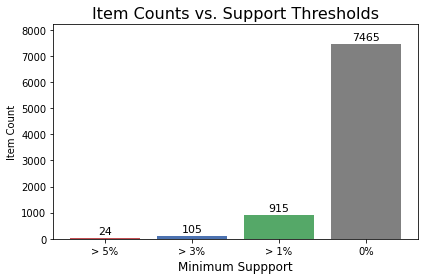

In [69]:
# try:
#     font = fm.FontProperties(fname='c:/Windows/Fonts/msjh.ttc') # Windows
# except FileNotFoundError:
#     try:
#         font = fm.FontProperties(fname='/System/Library/Fonts/PingFang.ttc') # macOS
#     except FileNotFoundError:
#         font = fm.FontProperties(fname='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc') # Linux
        
# plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots()

# # 準備繪圖數據
# thresholds = ['> 5%', '> 3%', '> 1%']
# counts = [len(frequent_items_05), len(frequent_items_03), len(frequent_items_01)]

# bars = ax.bar(thresholds, counts, color=['#55a868', '#c44e52', '#4c72b0'])

thresholds = ['> 5%', '> 3%', '> 1%', '0%']
counts = [len(frequent_items_05), len(frequent_items_03), len(frequent_items_01), unique_item_count]
bars = ax.bar(thresholds, counts, color=['#c44e52','#4c72b0', '#55a868', 'gray'])
# ax.set_yscale('log')

# 設置圖表標題和軸標籤
ax.set_xlabel('Minimum Suppport', fontsize=12)
ax.set_ylabel('Item Count')
ax.set_title('Item Counts vs. Support Thresholds', fontsize=16)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

# 在長條圖上顯示數字
for bar in bars:
    yval = bar.get_height()
    # 在長條圖上方顯示數字
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + max(counts)*0.01, int(yval), ha='center', va='bottom', fontsize=11)
    # y 軸是 log scale
    # ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.05, int(yval), ha='center', va='bottom', fontsize=11)


    
    


# 特別標示出核心實驗組
# # 找到 >5% 的長條
# core_bar = bars[0]
# core_bar.set_color('#ff9f4a') # 給予不同顏色
# core_bar.set_edgecolor('red')
# core_bar.set_linewidth(1.5)

# ax.annotate(
#     'core experiment group', 
#     xy=(core_bar.get_x() + core_bar.get_width() / 2, core_bar.get_height()+300.0), 
#     xytext=(core_bar.get_x() + 0.5, core_bar.get_height() + max(counts)*0.2),
#     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
#     ha='center', 
#     # fontproperties=font,
#     fontsize=12
# )

plt.tight_layout()
# ax.set_ylim(top=unique_item_count * 1.5)
ax.set_ylim(top=unique_item_count * 1.1)
plt.savefig('./figures/dataset_analysis/item_counts_vs_support_thresholds.png')
plt.show()


### 相同敘述商品 改成相同的編號

In [103]:
# StockCode 21213, 445473, 445452 都改成 21212
# 445473, 445452  改成 21212 (PACK OF 72 RETROSPOT CAKE CASES)
all_transactions = [[item if item != '21213' and item != '445473' and item != '445452' else '21212' for item in trx] for trx in all_transactions]

# 22456,471576
#  471597, 22457,NATURAL SLATE HEART CHALKBOARD
all_transactions = [[item if item != '471597' else '22457' for item in trx] for trx in all_transactions]

#  1787583, 1784538, 478884, 1783929, 456393, 447846, 1784370, 458115, 84978 to 85123A T-LIGHT HOLDER
all_transactions = [[item if item != '85123A' else '1787583' for item in trx] for trx in all_transactions]
# all_transactions = [[item if item != '1787583' and item != '1784538' and item != '478884' and item != '1783929' and item != '456393' and item != '447846' and item != '1784370' and item != '458115' and item != '84978' else '85123A' for item in trx] for trx in all_transactions]


In [ ]:
def create_filtered_dataset(transactions, num_items, num_target_transactions):
    """
    從總交易中，篩選出包含前N個最頻繁商品的交易子集。

    :param transactions: 完整的交易清單 (list of lists)
    :param num_items: 要保留的商品數量 (例如 12, 24, 36)
    :param num_target_transactions: 目標交易筆數 (例如 10000)
    :return: 篩選和抽樣後的交易資料集
    """
    # 1. 計算所有商品的頻率
    all_items = [item for sublist in transactions for item in sublist]
    item_counts = Counter(all_items)

    # 2. 取得前 N 個最頻繁的商品
    top_items = {item for item, count in item_counts.most_common(num_items)}
    print(f"\n已選取前 {num_items} 個最頻繁的商品: \n {list(top_items)}")

    # 3. 篩選交易：只保留包含這 N 個商品的交易
    #    並在交易中只保留這 N 個商品
    filtered_transactions = []
    for trx in transactions:
        filtered_trx = [item for item in trx if item in top_items]
        if filtered_trx: # 如果篩選後交易不為空
            filtered_transactions.append(list(set(filtered_trx))) # 使用 set 移除單筆交易中的重複商品

    print(f"篩選後，包含這 {num_items} 種商品的交易有 {len(filtered_transactions)} 筆。")

    # 4. 從篩選後的交易中隨機抽樣約 10000 筆
    # if len(filtered_transactions) < num_target_transactions:
    #     print(f"警告：篩選後的交易數少於目標 {num_target_transactions} 筆，將使用所有篩選結果。")
    #     return filtered_transactions
    
    # 使用 pandas 進行隨機抽樣更方便
    # sampled_df = pd.Series(filtered_transactions).sample(n=num_target_transactions, random_state=42)
    # return sampled_df.to_list()

    # 把只有單個商品的刪掉
    filtered_transactions = [trx for trx in filtered_transactions if len(trx) > 1]

    # 用全部的交易
    return filtered_transactions

# --- 生成您需要的三個資料集 ---
target_transactions_count = 10000

# 資料集 1: 12 種商品，約 10000 筆交易
dataset_12_items = create_filtered_dataset(all_transactions, 12, target_transactions_count)
print(f"成功生成資料集1：包含 {len(dataset_12_items)} 筆交易，商品種類限制在 12 種。")
print("範例:", dataset_12_items[:20])


# 資料集 2: 24 種商品，約 10000 筆交易
dataset_24_items = create_filtered_dataset(all_transactions, 24, target_transactions_count)
print(f"成功生成資料集2：包含 {len(dataset_24_items)} 筆交易，商品種類限制在 24 種。")
print("範例:", dataset_24_items[:3])


# 資料集 3: 36 種商品，約 10000 筆交易
dataset_36_items = create_filtered_dataset(all_transactions, 36, target_transactions_count)
print(f"成功生成資料集3：包含 {len(dataset_36_items)} 筆交易，商品種類限制在 36 種。")
print("範例:", dataset_36_items[:3])

# 已選取前 12 個最頻繁的商品: 
#  ['21212', '22457', '22720', '85099B', '22197', '84879', '22383', '85123A', '20727', '22423', '20725', '47566']
# 篩選後，包含這 12 種商品的交易有 10084 筆。
# 成功生成資料集1：包含 4612 筆交易，商品種類限制在 12 種。
# 範例: [['21212', '20725'], ['22197', '85099B', '85123A'], ['84879', '21212'], ['85123A', '20725'], ['22197', '21212', '20727', '22383'], ['84879', '21212'], ['22197', '85099B'], ['22197', '20727', '22383', '20725'], ['22197', '84879', '21212', '85099B'], ['84879', '22423', '85123A'], ['22197', '85123A'], ['22197', '21212'], ['85123A', '20727', '85099B', '22383'], ['21212', '22457', '20725', '85099B', '22197', '22383', '85123A', '22423'], ['85099B', '85123A'], ['20727', '85099B', '85123A'], ['22457', '85123A'], ['21212', '20725', '85099B', '22197', '84879', '85123A', '20727', '22423'], ['22457', '85099B', '84879', '22423', '85123A'], ['20727', '22457']]

# 大已選取前 12 個最頻繁的商品: 
#  ['1786029', '1787583', '445452', '470883', '1784937', '1776516', '1782459', '477120', '466137', '998886', '1787079', '435225']
# 篩選後，包含這 12 種商品的交易有 10296 筆。
# 成功生成資料集1：包含 4487 筆交易，商品種類限制在 12 種。
# 範例: [['1787079', '435225', '1784937', '445452'], ['1787583', '1787079', '466137'], ['1782459', '445452'], ['1787583', '1786029', '435225'], ['1786029', '445452', '466137'], ['1782459', '445452', '1784937'], ['1787079', '466137'], ['1786029', '435225', '466137'], ['1786029', '445452'], ['1782459', '466137', '1787079', '445452'], ['1782459', '1787583', '470883'], ['1787583', '1776516', '466137'], ['1787079', '1784937'], ['1786029', '470883'], ['445452', '466137'], ['1787583', '1787079'], ['1786029', '1787583', '445452', '470883', '466137', '1787079', '435225'], ['1787583', '1787079'], ['1787583', '1787079'], ['1786029', '1787583', '445452', '470883', '1776516', '1782459', '466137', '998886', '1787079', '435225']]

######################ˇ
# 已選取前 24 個最頻繁的商品: 
#  ['21212', '22382', '22720', '22469', '22666', '20725', '47566', '22961', '20727', 'POST', '22411', '21931', '85099B', '22086', '22197', '20728', '85123A', '22423', '22457', '22960', '84879', '22386', '22383', '23203']
# 篩選後，包含這 24 種商品的交易有 12825 筆。
# 成功生成資料集2：包含 7236 筆交易，商品種類限制在 24 種。
# 範例: [['21931', '21212', '22386', '20725'], ['22086', '22411'], ['22469', '22457']]

# 大 已選取前 24 個最頻繁的商品: 
#  ['1784937', '1782459', '435267', '466137', '998886', '1786029', '1787583', '445452', '482160', '487263', '477120', '460551', '463806', '470106', '1776516', '435225', '471597', '471849', '470022', '1787079', '470631', '470883', '470043', '435288']
# 篩選後，包含這 24 種商品的交易有 12350 筆。
# 成功生成資料集2：包含 7125 筆交易，商品種類限制在 24 種。
# 範例: [['445452', '1784937', '460551', '470106', '1787079', '435225'], ['463806', '470631'], ['471849', '471597']]

###################
# 已選取前 36 個最頻繁的商品: 
#  ['21212', '22382', '23298', '22720', '22469', '22666', '22699', '20725', '47566', '22178', '22697', '22961', '20727', 'POST', '22411', '21931', '20724', '85099B', '22086', '22197', '20728', '85123A', '22423', '22993', '22457', '23209', '22960', '82482', '23206', '84879', '22386', '22383', '22384', '23203', '22727', '23084']
# 篩選後，包含這 36 種商品的交易有 14283 筆。
# 成功生成資料集3：包含 9057 筆交易，商品種類限制在 36 種。
# 範例: [['POST', '22727'], ['82482', '85123A'], ['82482', '85123A']]


# 大 已選取前 36 個最頻繁的商品: 
#  ['489258', '1784370', '1784937', '1782459', '435267', '466137', '482853', '998886', '1732122', '487389', '477267', '1786029', '1787583', '445452', '482160', '487263', '477120', '460551', '463806', '470106', '1776516', '435225', '471597', '482181', '471849', '470064', '470022', '1787079', '470631', '85123A', '316176', '470883', '476679', '470043', '475986', '435288']
# 篩選後，包含這 36 種商品的交易有 15925 筆。
# 成功生成資料集3：包含 8828 筆交易，商品種類限制在 36 種。
# 範例: [['1732122', '1787583'], ['1732122', '1787583'], ['445452', '1784937', '460551', '470106', '1787079', '435225']]


已選取前 12 個最頻繁的商品: 
 ['1787583', '21212', '22457', '1786029', '470883', '1784937', '1776516', '1782459', '477120', '998886', '1787079', '435225']
篩選後，包含這 12 種商品的交易有 14559 筆。
成功生成資料集1：包含 5238 筆交易，商品種類限制在 12 種。
範例: [['1787583', '21212', '22457'], ['1787583', '22457'], ['1787583', '21212'], ['1787583', '22457'], ['1787583', '21212'], ['1787583', '21212', '22457'], ['1787583', '21212', '22457'], ['21212', '22457'], ['1787583', '21212', '22457'], ['1787583', '21212', '22457'], ['1787583', '22457'], ['1787583', '22457'], ['1787583', '21212', '22457'], ['1787583', '22457'], ['1787583', '21212'], ['1787583', '21212', '22457'], ['1787583', '21212', '22457'], ['1787583', '21212'], ['1787583', '22457'], ['1787583', '21212', '22457']]

已選取前 24 個最頻繁的商品: 
 ['21212', '1784937', '1782459', '435267', '466137', '998886', '1787583', '1786029', '482160', '487263', '477120', '460551', '463806', '470106', '1776516', '435225', '471849', '470022', '1787079', '470631', '22457', '470883', '470043', '435288']
篩選後

In [106]:
# 儲存資料集到csv檔案
import csv
def save_dataset_to_csv(dataset, filename):
    with open(filename , 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        for transaction in dataset:
            writer.writerow(transaction)

# 儲存資料集1
print(f"儲存資料集1 {len(dataset_12_items)} 筆交易到 dataset_12_items.csv")
save_dataset_to_csv(dataset_12_items, 'dataset_12_items.csv')
# 儲存資料集2
print(f"儲存資料集2 {len(dataset_24_items)} 筆交易到 dataset_24_items.csv")
save_dataset_to_csv(dataset_24_items, 'dataset_24_items.csv')
# 儲存資料集3
print(f"儲存資料集3 {len(dataset_36_items)} 筆交易到 dataset_36_items.csv")
save_dataset_to_csv(dataset_36_items, 'dataset_36_items.csv')

儲存資料集1 5238 筆交易到 dataset_12_items.csv
儲存資料集2 7864 筆交易到 dataset_24_items.csv
儲存資料集3 9677 筆交易到 dataset_36_items.csv


### 確認商品名稱

In [ ]:
# 用invoiceNo找description
invoice_to_description = df.groupby('StockCode')['Description'].apply(list).to_dict()

# drop 敘述相同的項目
for key, value in invoice_to_description.items():
    invoice_to_description[key] = list(set(value))
    

check_no = ['21212', '22457', '22720', '85099B', '22197', '84879', '22383', '85123A', '20727', '22423', '20725', '47566']
for no in check_no:
    if no in invoice_to_description:
        print(f"InvoiceNo {no} 的商品描述: {invoice_to_description[no]}")
    else:
        print(f"InvoiceNo {no} 不存在於資料中。")

InvoiceNo 21212 的商品描述: ['PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASES', 'PACK OF 72 RETROSPOT CAKE CASE

In [105]:
# 用 item code 找description
code_to_description = df_kaggle.groupby('ItemCode')['ItemDescription'].apply(list).to_dict()

# drop 敘述相同的項目
for key, value in code_to_description.items():
    code_to_description[key] = list(set(value))
    

# check_no = ['21212', '22457', '22720', '85099B', '22197', '84879', '22383', '85123A', '20727', '22423', '20725', '47566']
# check_code = ['1786029', '1787583', '445452', '470883', '1784937', '1776516', '1782459', '477120', '466137', '998886', '1787079', '435225']
check_code = ['21212', '1784937', '1782459', '435267', '466137', '998886', '1787583', '1786029', '482160', '487263', '477120', '460551', '463806', '470106', '1776516', '435225', '471849', '470022', '1787079', '470631', '22457', '470883', '470043', '435288']

for no in check_code:
    if no in code_to_description:
        print(f"InvoiceNo {no} 的商品描述: {code_to_description[no]}")
    else:
        print(f"InvoiceNo {no} 不存在於資料中。")

InvoiceNo 21212 不存在於資料中。
InvoiceNo 1784937 的商品描述: ['?', 'CHILDRENS CUTLERY POLKADOT PINK', 'CHILDRENS CUTLERY RETROSPOT RED ', 'RED 3 PIECE RETROSPOT CUTLERY SET', 'CHILDRENS CUTLERY POLKADOT GREEN ', 'GREEN 3 PIECE POLKADOT CUTLERY SET', 'CHILDRENS CUTLERY POLKADOT BLUE', 'BLUE 3 PIECE POLKADOT CUTLERY SET', 'PINK 3 PIECE POLKADOT CUTLERY SET']
InvoiceNo 1782459 的商品描述: ['ASSORTED COLOUR BIRD ORNAMENT', 'damaged']
InvoiceNo 435267 的商品描述: ['LUNCH BAG  BLACK SKULL.']
InvoiceNo 466137 的商品描述: ['SMALL POPCORN HOLDER', 'POPCORN HOLDER']
InvoiceNo 998886 的商品描述: ['PARTY BUNTING', 'reverse previous adjustment', 'TEA TIME PARTY BUNTING', 'incorrectly credited C550456 see 47']
InvoiceNo 1787583 的商品描述: ['?', 'WHITE HANGING HEART T-LIGHT HOLDER', 'wrongly marked carton 22804', 'CREAM HANGING HEART T-LIGHT HOLDER']
InvoiceNo 1786029 的商品描述: [nan, 'BABY BOOM RIBBONS ', 'SCANDINAVIAN REDS RIBBONS', 'BRIGHT BLUES RIBBONS ', '?', 'ROMANTIC PINKS RIBBONS ', 'LUSH GREENS RIBBONS', 'URBAN BLACK RIBBONS ', '

In [28]:
import pandas as pd

# 假設 df 已經成功讀取
# 為了避免因為同一個StockCode有多個微小差異的Description，我們先去除重複
# 這會保留每個 StockCode 第一次出現時的 Description
stock_desc_map = df[['StockCode', 'Description']].drop_duplicates()

# 建立一個以 StockCode 為鍵，Description 為值的字典
# set_index() 是非常高效的方法
stock_to_desc_dict = stock_desc_map.set_index('StockCode')['Description'].to_dict()

# 我們可以印出來看看字典的一小部分內容
import itertools
print(dict(itertools.islice(stock_to_desc_dict.items(), 5)))

{'85123A': 'CREAM HANGING HEART T-LIGHT HOLDER', '71053': 'WHITE MOROCCAN METAL LANTERN', '84406B': nan, '84029G': nan, '84029E': nan}


In [29]:
# 您的清單，實際上是 StockCode 清單
check_codes = ['21212', '22457', '22720', '85099B', '22197', '84879', '22383', '85123A', '20727', '22423', '20725', '47566']

print("--- 開始查詢商品描述 ---")
for code in check_codes:
    if code in stock_to_desc_dict:
        # 從我們新建立的正確字典中查詢
        description = stock_to_desc_dict[code]
        print(f"StockCode '{code}' 的商品描述: {description}")
    else:
        print(f"StockCode '{code}' 不存在於資料中。")

--- 開始查詢商品描述 ---
StockCode '21212' 的商品描述: PACK OF 72 RETROSPOT CAKE CASES
StockCode '22457' 的商品描述: NATURAL SLATE HEART CHALKBOARD 
StockCode '22720' 的商品描述: nan
StockCode '85099B' 的商品描述: JUMBO BAG RED RETROSPOT
StockCode '22197' 的商品描述: POPCORN HOLDER
StockCode '84879' 的商品描述: damaged
StockCode '22383' 的商品描述: LUNCH BAG SUKI DESIGN 
StockCode '85123A' 的商品描述: CREAM HANGING HEART T-LIGHT HOLDER
StockCode '20727' 的商品描述: LUNCH BAG  BLACK SKULL.
StockCode '22423' 的商品描述: damages
StockCode '20725' 的商品描述: LUNCH BAG RED SPOTTY
StockCode '47566' 的商品描述: PARTY BUNTING
